## Load Data or Create Data

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

RAW_CSV_DIR = "data/df.csv"
CLEAN_CSV_DIR = "data/cleaned_df.csv"

# 0 -> ham, 1 -> phish, 2 -> spam
LABELS = {0 : 'ham', 1: 'phish', 2: 'spam'}

# load or create clean data
if os.path.exists(CLEAN_CSV_DIR):
    print(f"Found existing cleaned dataset at {CLEAN_CSV_DIR}. Loading instantly...")
    df = pd.read_csv(CLEAN_CSV_DIR)
    
else:
    print(f"Cleaned dataset not found. Loading raw data from {RAW_CSV_DIR}...")
    df = pd.read_csv(RAW_CSV_DIR)
    df = df.dropna(subset=['text'])
    
    ps = PorterStemmer()
    tqdm.pandas()
    
    def clean_spam_text(text):
        if not isinstance(text, str):
            return ""
        return ' '.join([ps.stem(word) for word in text.split()])

    # this take ~15 min
    df['cleaned_text'] = df['text'].progress_apply(clean_spam_text)
    
    df.to_csv(CLEAN_CSV_DIR, index=False)
    print("Saved successfully!")

df = df.dropna(subset=['cleaned_text', 'label'])
df = df[df['cleaned_text'].astype(str).str.strip() != '']

print(f"Dataset ready! Shape: {df.shape}")

Found existing cleaned dataset at data/cleaned_df.csv. Loading instantly...
Dataset ready! Shape: (365445, 3)


# Perform Exploratory Data Analysis

## Class-based EDA

--- Exploratory Data Analysis ---

Examples per class:
Class_Name
Ham         168454
Spam        154147
Phishing     42844
Name: count, dtype: int64


/var/folders/6m/1mxqdcnn1j5439r34cg13h840000gn/T/ipykernel_82730/1618537597.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class_Name', order=['Ham', 'Spam', 'Phishing'],
/var/folders/6m/1mxqdcnn1j5439r34cg13h840000gn/T/ipykernel_82730/1618537597.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class_Name', y='word_count',


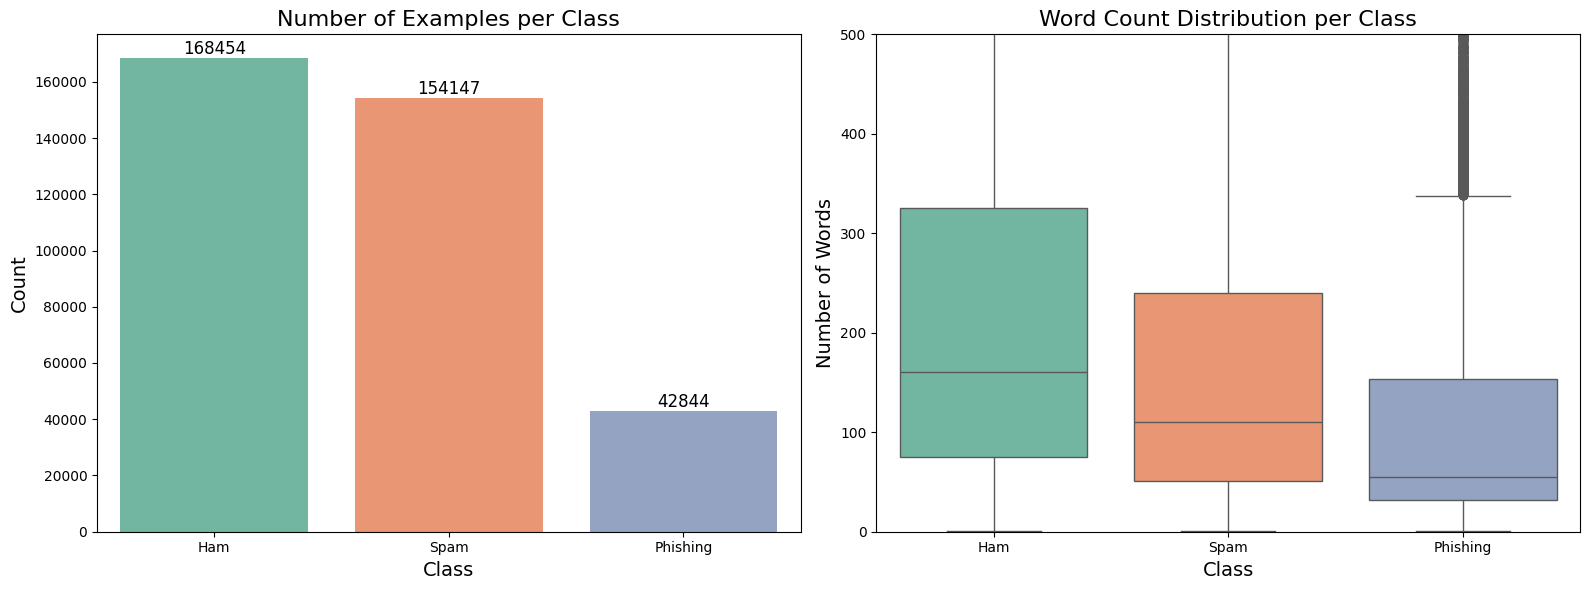

In [2]:
print("--- Exploratory Data Analysis ---")

label_names = {0: 'Ham', 1: 'Phishing', 2: 'Spam'}
df['Class_Name'] = df['label'].map(label_names)

# Calculate exact counts
class_counts = df['Class_Name'].value_counts()
print("\nExamples per class:")
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Class Distribution (Bar Chart) ---
sns.countplot(data=df, x='Class_Name', order=['Ham', 'Spam', 'Phishing'], 
              palette='Set2', ax=axes[0])
axes[0].set_title('Number of Examples per Class', fontsize=16)
axes[0].set_xlabel('Class', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12)

# --- PLOT 2: Word Count Distribution (Boxplot) ---
df['word_count'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='Class_Name', y='word_count', 
            order=['Ham', 'Spam', 'Phishing'], palette='Set2', ax=axes[1])
axes[1].set_title('Word Count Distribution per Class', fontsize=16)
axes[1].set_xlabel('Class', fontsize=14)
axes[1].set_ylabel('Number of Words', fontsize=14)
axes[1].set_ylim(0, 500) 

plt.tight_layout()
plt.show()

## WordCloud per Class

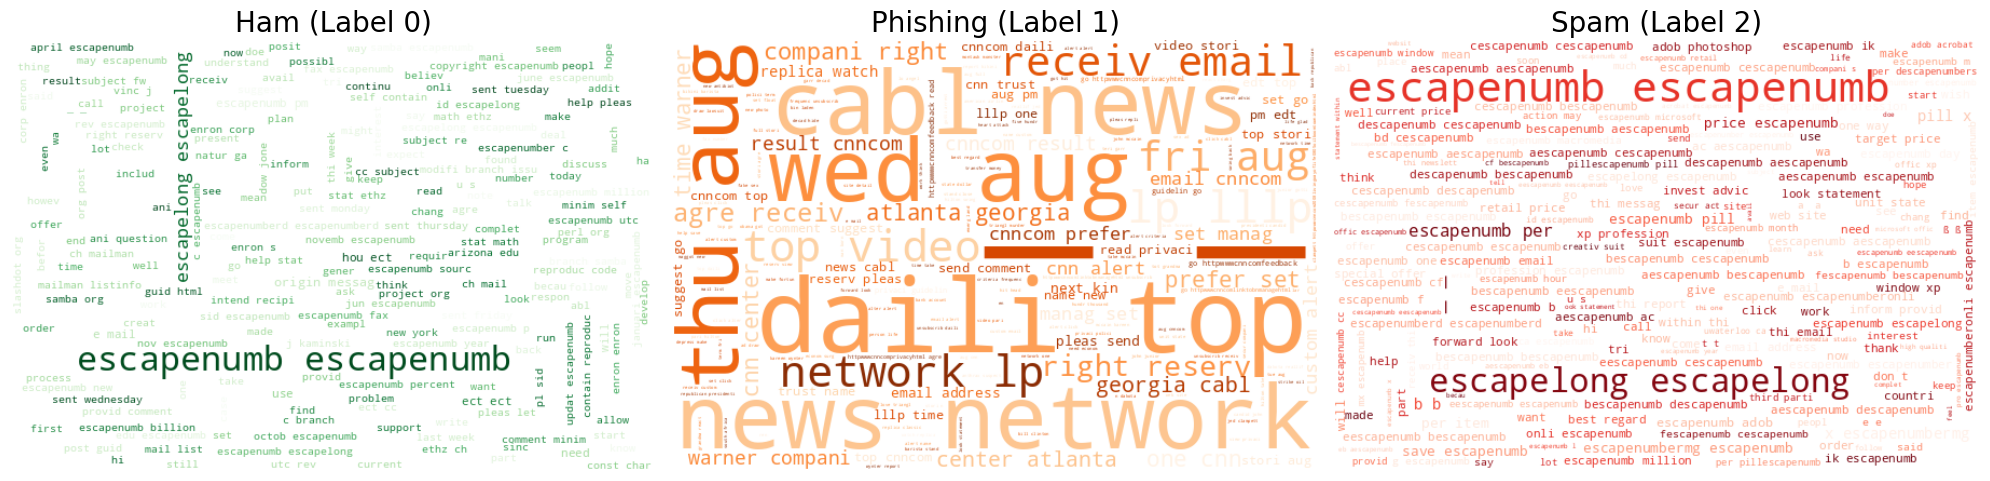

In [3]:
df_ham = df[df['label'] == 0]
df_phish = df[df['label'] == 1]
df_spam = df[df['label'] == 2]

ham_text = " ".join(df_ham['cleaned_text'].astype(str))
phish_text = " ".join(df_phish['cleaned_text'].astype(str))
spam_text = " ".join(df_spam['cleaned_text'].astype(str))

wc_ham = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens').generate(ham_text)
wc_phish = WordCloud(width=600, height=400, background_color='white', 
                     colormap='Oranges').generate(phish_text)
wc_spam = WordCloud(width=600, height=400, background_color='white', 
                    colormap='Reds').generate(spam_text)

fig, axs = plt.subplots(1, 3, figsize=(20, 6))

axs[0].imshow(wc_ham, interpolation='bilinear')
axs[0].set_title('Ham (Label 0)', fontsize=20)
axs[0].axis('off')

axs[1].imshow(wc_phish, interpolation='bilinear')
axs[1].set_title('Phishing (Label 1)', fontsize=20)
axs[1].axis('off')

axs[2].imshow(wc_spam, interpolation='bilinear')
axs[2].set_title('Spam (Label 2)', fontsize=20)
axs[2].axis('off')

plt.tight_layout()
plt.show()

## TF-IDF Scoring


--- Dataset Summary Statistics ---


,Total Samples,Avg Word Count,Median Word Count,Vocabulary Size
label,,,,
0,168454,346.26,161.0,243952
1,42844,121.35,55.0,329784
2,154147,209.37,110.0,326462


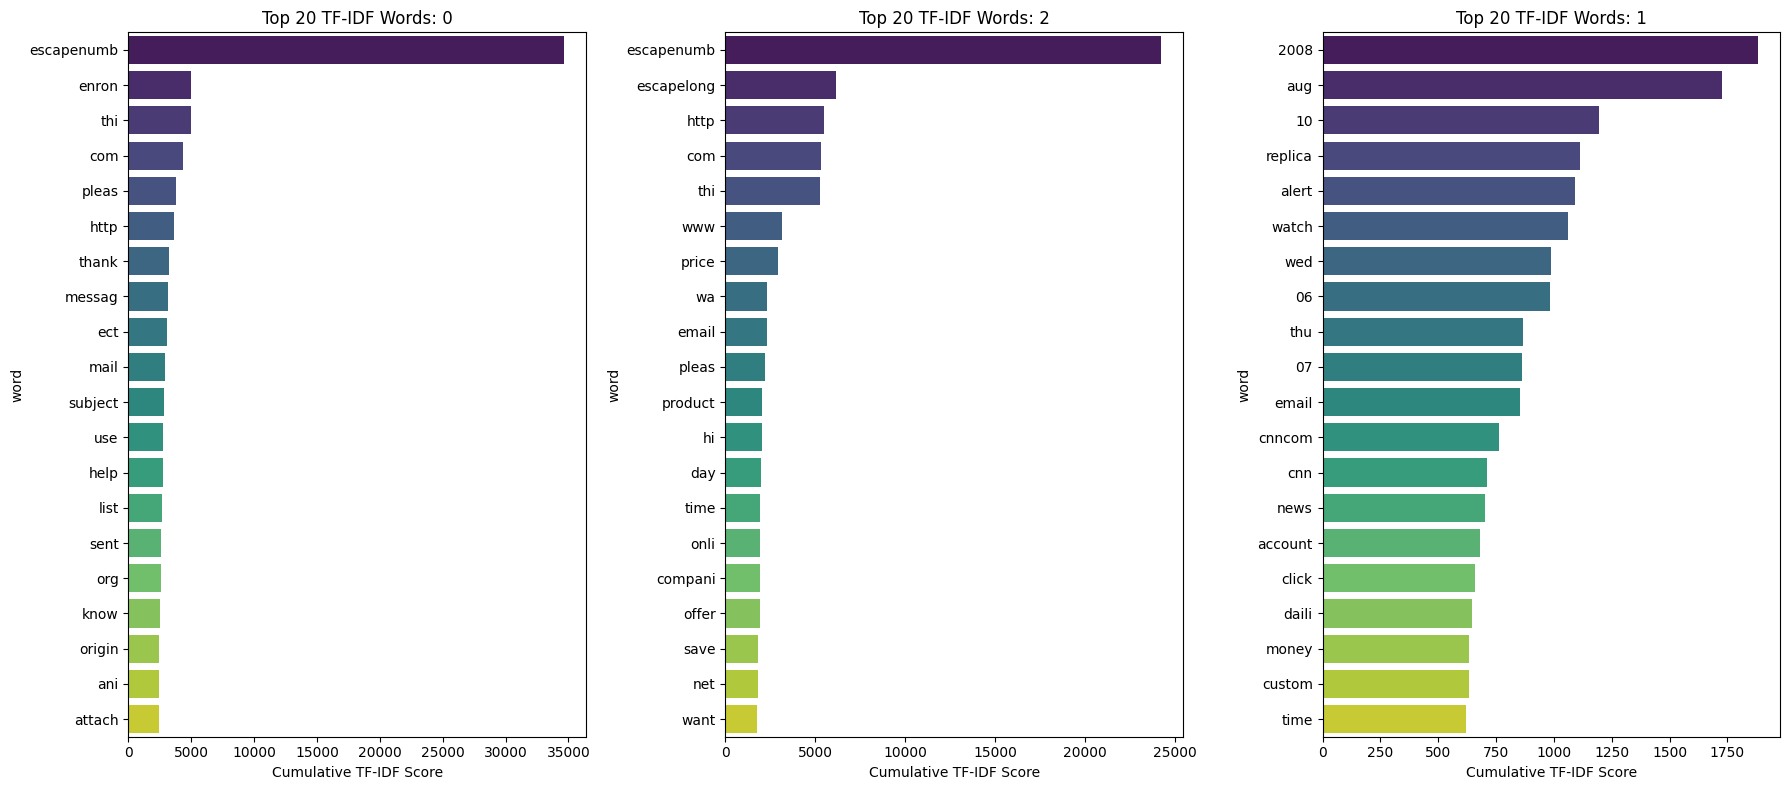

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pre-processing check
df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)

# setup for table
summary = df.groupby('label')['word_count'].agg(['count', 'mean', 'median']).rename(
    columns={'count': 'Total Samples', 'mean': 'Avg Word Count', 'median': 'Median Word Count'}
)

# dictionary to store the vocabulary sizes we find during the loop
vocab_sizes = {}

# combined Loop for visualization and vocab counting
classes = df['label'].unique()
plt.figure(figsize=(18, 8))

# define the vectorizer for the visualization (with max_features to keep charts readable and min_df to avoid noise)
tfidf_viz = TfidfVectorizer(max_features=5000, stop_words='english', min_df=2)

# define a separate vectorizer for the summary table (no max_features to get the FULL vocab size and no min_df)
tfidf_full = TfidfVectorizer(stop_words='english')

for i, class_label in enumerate(classes):
    class_text = df[df['label'] == class_label]['cleaned_text']
    
    # skip if class is empty
    if class_text.str.strip().replace('', None).dropna().empty:
        vocab_sizes[class_label] = 0
        continue

    try:
        # --- PART A: CALCULATE FULL VOCABULARY SIZE ---
        tfidf_full.fit(class_text)
        vocab_sizes[class_label] = len(tfidf_full.vocabulary_)

        # --- PART B: GENERATE TF-IDF VISUALIZATION ---
        tfidf_matrix = tfidf_viz.fit_transform(class_text)
        sums = tfidf_matrix.sum(axis=0)
        
        data = []
        for col, idx in tfidf_viz.vocabulary_.items():
            data.append((col, sums[0, idx]))

        ranking = pd.DataFrame(data, columns=['word', 'tfidf_score'])
        ranking = ranking.sort_values('tfidf_score', ascending=False).head(20)

        #  plot
        plt.subplot(1, len(classes), i+1)
        sns.barplot(
            x='tfidf_score', 
            y='word', 
            data=ranking, 
            hue='word', 
            palette='viridis', 
            legend=False
        )
        plt.title(f'Top 20 TF-IDF Words: {class_label}')
        plt.xlabel('Cumulative TF-IDF Score')
        
    except ValueError as e:
        print(f"Could not process class '{class_label}': {e}")
        vocab_sizes[class_label] = 0

# finalize and display table
summary['Vocabulary Size'] = pd.Series(vocab_sizes)
print("\n--- Dataset Summary Statistics ---")
display(summary.round(2))

plt.tight_layout()
plt.show()

## Bigrams and Trigrams

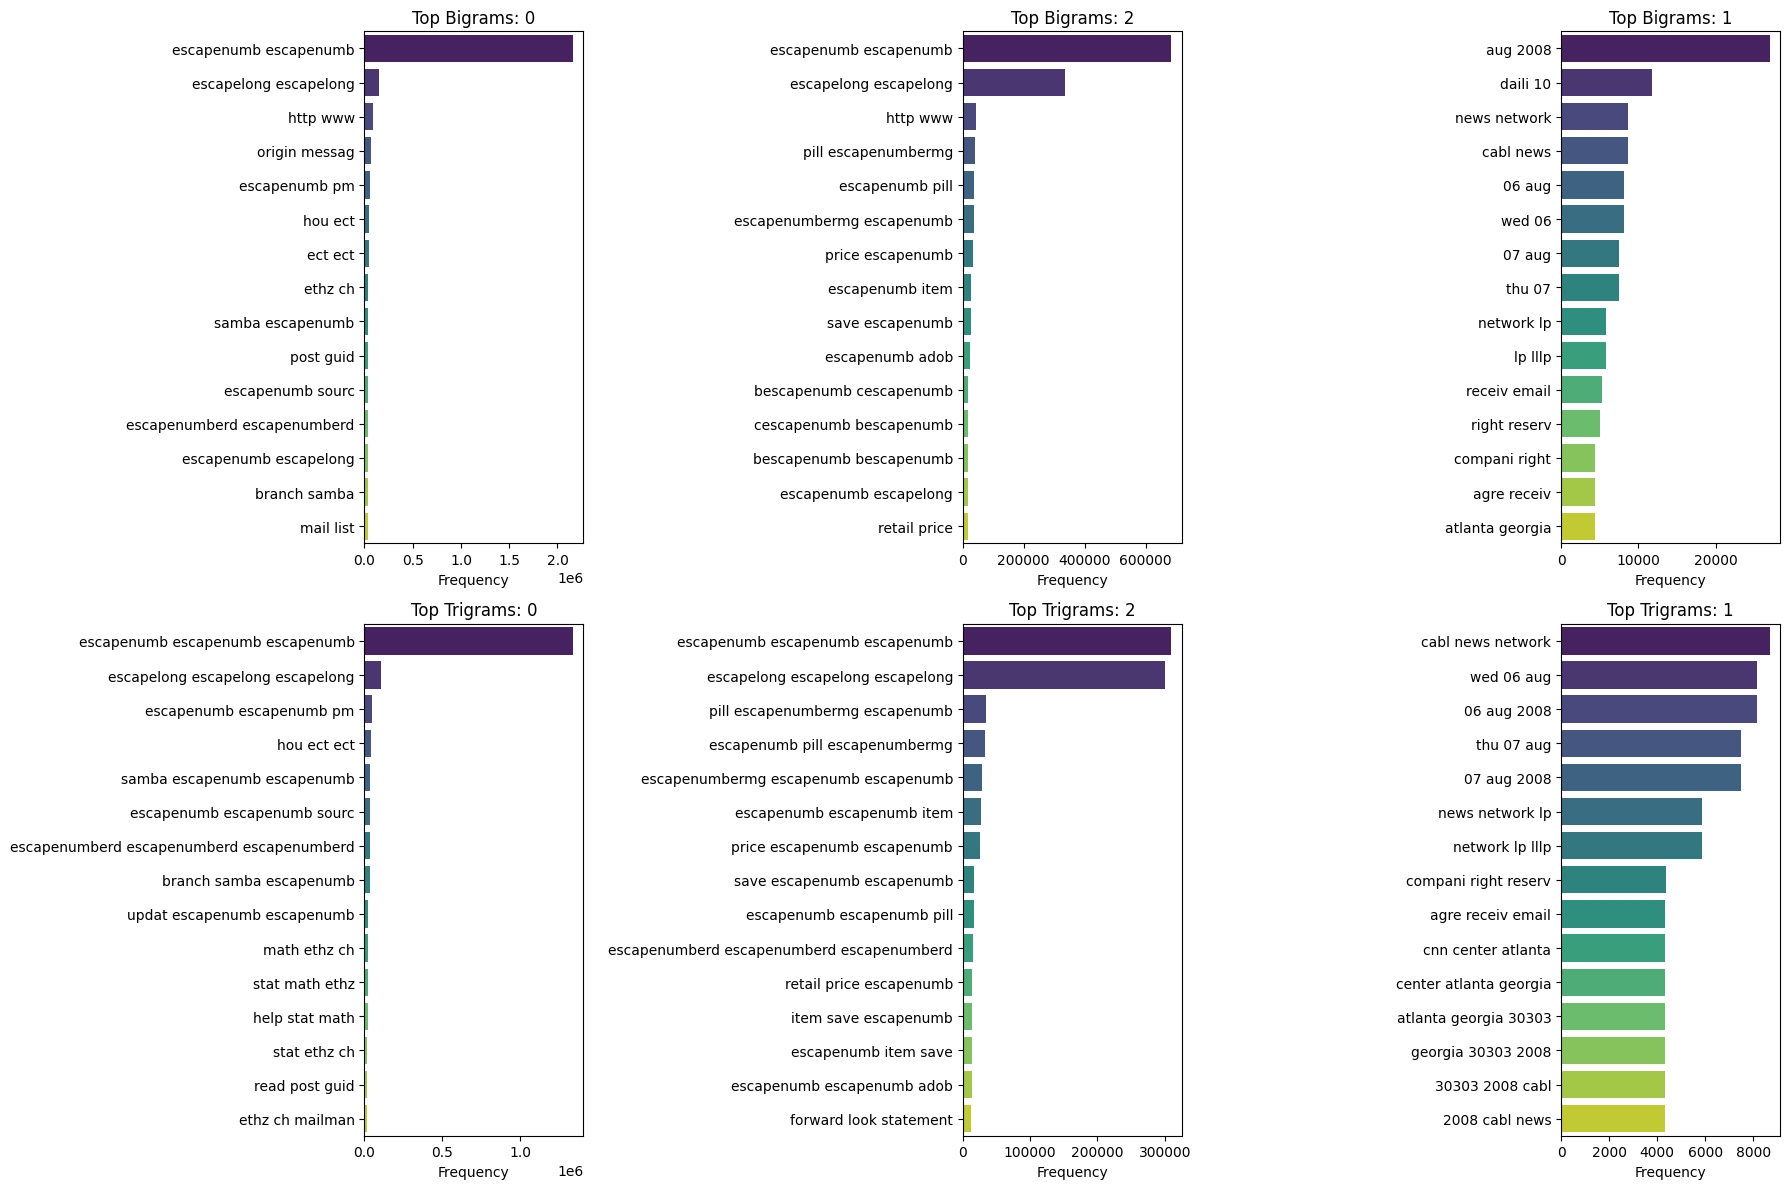

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_ngrams(corpus, title, n=2, top_n=15):
    # filter out empty or whitespace-only strings
    corpus = [doc for doc in corpus if str(doc).strip()]
    
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_n]
    
    words, counts = zip(*words_freq)
    
    sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='viridis', legend=False)
    plt.title(title)
    plt.xlabel('Frequency')

# plotting Bigrams (n=2)
plt.figure(figsize=(18, 12))
classes = df['label'].unique()

for i, cls in enumerate(classes):
    plt.subplot(2, 3, i+1)
    plot_top_ngrams(df[df['label']==cls]['cleaned_text'], f'Top Bigrams: {cls}', n=2)

# plotting Trigrams (n=3)
for i, cls in enumerate(classes):
    plt.subplot(2, 3, i+4)
    plot_top_ngrams(df[df['label']==cls]['cleaned_text'], f'Top Trigrams: {cls}', n=3)

plt.tight_layout()
plt.show()

## Character-Level Features

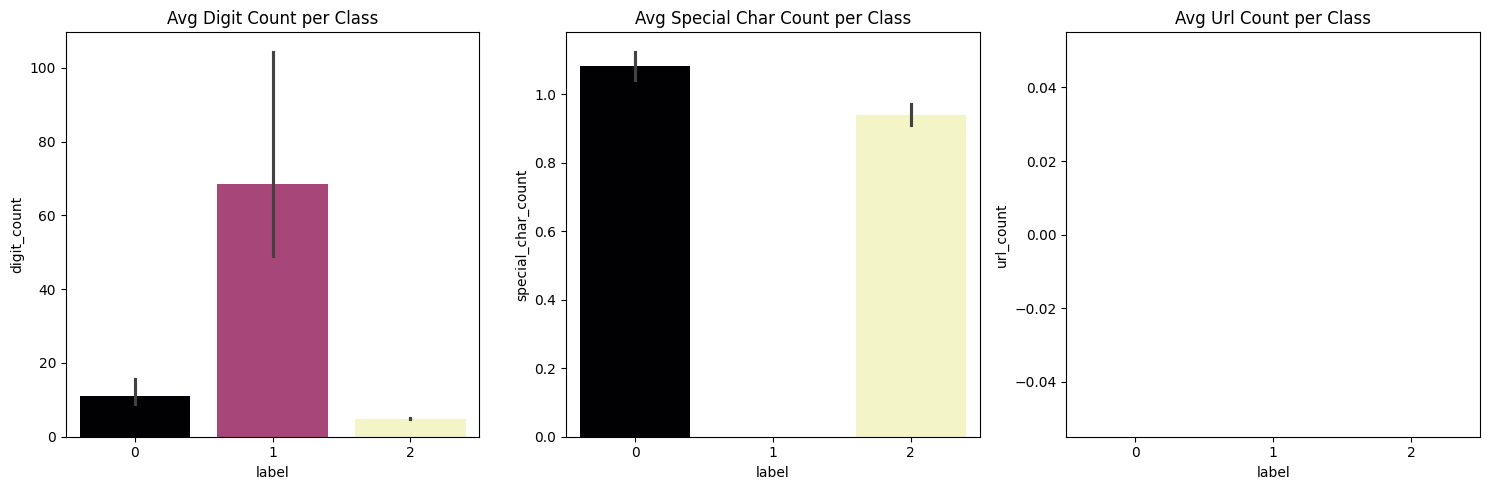

In [8]:
import re

# Function to count patterns
def get_char_features(text):
    text = str(text)
    return pd.Series({
        'digit_count': len(re.findall(r'\d', text)),
        'special_char_count': len(re.findall(r'[!$%&*@#]', text)),
        'url_count': len(re.findall(r'https?://\S+|www\.\S+', text)),
        'char_count': len(text)
    })

# Apply to the original text column (assuming it's called 'text')
char_features = df['text'].apply(get_char_features)
df_with_chars = pd.concat([df, char_features], axis=1)

# Visualize averages per class
plt.figure(figsize=(15, 5))
feature_cols = ['digit_count', 'special_char_count', 'url_count']

for i, col in enumerate(feature_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df_with_chars, x='label', y=col, palette='magma', hue='label', legend=False)
    plt.title(f'Avg {col.replace("_", " ").title()} per Class')

plt.tight_layout()
plt.show()